In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

In [46]:
# Reviews nettoyées (niveau review)
reviews = pd.read_csv("../data/processed/amazon_reviews_cleaned.csv")

# Features user (niveau user)
df_users = pd.read_csv("../data/processed/user_behavior_features.csv")



df_users.head()


,user_id,nb_interactions,recency_days,nb_products,category_entropy,avg_rating,rating_std,avg_review_length,avg_sentiment,weekend_activity_ratio
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1,1840,1,-0.0,0.557747,0.000000,17.000000,0.416667,1.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,1,4840,1,-0.0,0.557747,0.000000,59.000000,0.251389,0.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,2,1,2,-0.0,0.557747,0.000000,40.500000,0.240655,0.000000
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,9,1219,9,-0.0,0.158272,1.198424,9.333333,0.439947,0.333333
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,3,596,3,-0.0,-0.041465,0.518933,18.666667,0.184028,0.000000


In [47]:
reviews = pd.read_csv("../data/processed/amazon_reviews_cleaned.csv")

reviews["like"] = (reviews["rating"] >= 4).astype(int)
reviews["like"].value_counts(normalize=True)



like
1    0.842735
0    0.157265
Name: proportion, dtype: float64

In [48]:
reviews.columns
df_users.columns

Index(['user_id', 'nb_interactions', 'recency_days', 'nb_products',
       'category_entropy', 'avg_rating', 'rating_std', 'avg_review_length',
       'avg_sentiment', 'weekend_activity_ratio'],
      dtype='object')

In [49]:
data = reviews.merge(df_users, on="user_id", how="left")

print(data.shape)
data[["user_id","asin","rating"]].head()


(20990, 24)


,user_id,asin,rating
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B083NRGZMM,3.0
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07N69T6TM,1.0
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B01G8JO5F2,5.0
3,AGGZ357AO26RQZVRLGU4D4N52DZQ,B001OC5JKY,5.0
4,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,B013J7WUGC,5.0


In [50]:
data["like"] = (data["rating"] >= 4).astype(int)
data["like"].value_counts(normalize=True)


like
1    0.842735
0    0.157265
Name: proportion, dtype: float64

In [51]:
feature_cols = [
    'nb_interactions', 'recency_days', 'nb_products',
       'category_entropy', 'avg_rating', 'rating_std', 'avg_review_length',
       'avg_sentiment', 'weekend_activity_ratio'  # optionnel si présent
]

# garder uniquement celles qui existent vraiment
feature_cols = [c for c in feature_cols if c in data.columns]

X = data[feature_cols].fillna(0)
y = data["like"]


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.71      0.27      0.39       660
           1       0.88      0.98      0.93      3538

    accuracy                           0.87      4198
   macro avg       0.80      0.63      0.66      4198
weighted avg       0.85      0.87      0.84      4198

ROC AUC: 0.8296801394384774


In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)


Best params: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
Best CV ROC AUC: 0.8337341890708767


In [55]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.40      0.65      0.49       660
           1       0.93      0.82      0.87      3538

    accuracy                           0.79      4198
   macro avg       0.66      0.73      0.68      4198
weighted avg       0.84      0.79      0.81      4198

Test ROC AUC: 0.831574078832417


In [56]:
coef = best_model.named_steps["clf"].coef_[0]
importance = pd.Series(coef, index=feature_cols).sort_values()
importance


rating_std               -0.430861
category_entropy         -0.059915
avg_review_length        -0.008641
nb_interactions          -0.004498
nb_products              -0.004498
weekend_activity_ratio    0.042427
avg_sentiment             0.106939
recency_days              0.161566
avg_rating                1.123663
dtype: float64

In [57]:
def recommend_supervised(user_id, top_n=5):
    user_id = str(user_id).strip()
    subset = data[data["user_id"] == user_id].copy()
    if subset.empty:
        return pd.DataFrame(columns=["asin", "like_proba"])

    X_sub = subset[feature_cols].fillna(0)
    subset["like_proba"] = best_model.predict_proba(X_sub)[:, 1]

    # On recommande les asins avec la plus forte proba
    recs = (
        subset.groupby("asin")["like_proba"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    return recs

recommend_supervised(data["user_id"].iloc[0], top_n=5)


,asin,like_proba
0,0593138228,0.198584
1,0593235657,0.198584
2,B09BGPFTDB,0.198584
3,B096S6LZV4,0.198584
4,B096N5WK8Q,0.198584


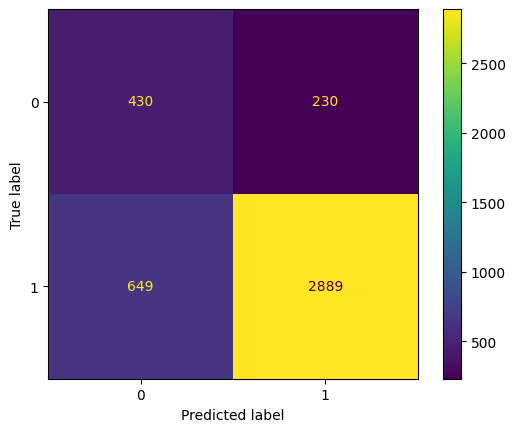

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()


In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.399     0.652     0.495       660
           1      0.926     0.817     0.868      3538

    accuracy                          0.791      4198
   macro avg      0.662     0.734     0.681      4198
weighted avg      0.843     0.791     0.809      4198



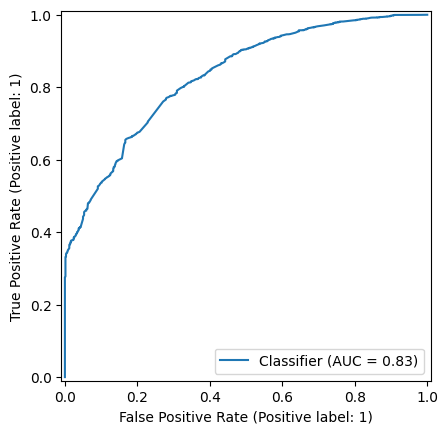

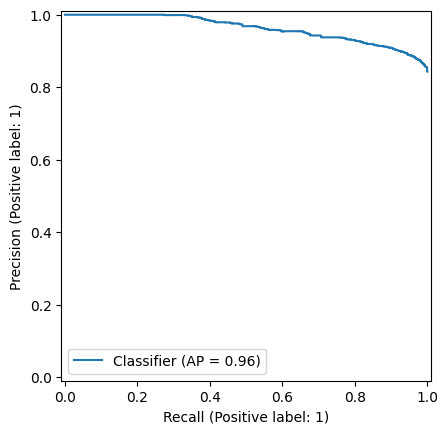

In [60]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
PrecisionRecallDisplay.from_predictions(y_test, y_proba)


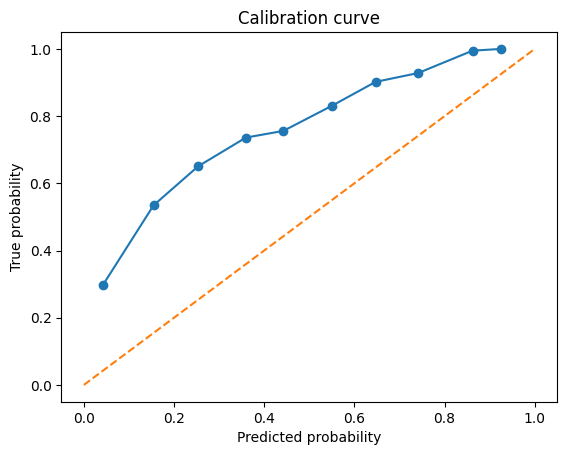

0.1642307093363947

In [61]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration curve")
plt.show()

brier_score_loss(y_test, y_proba)


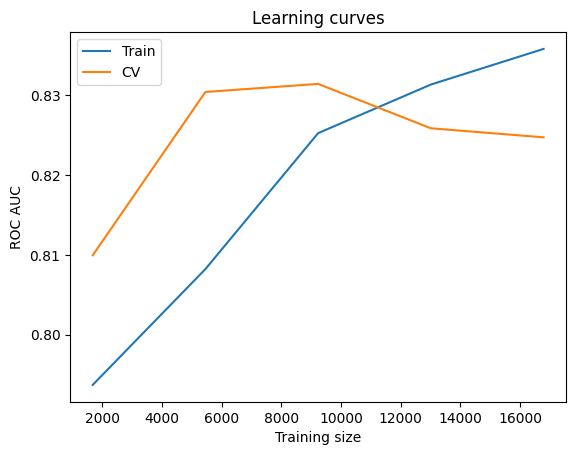

In [62]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=5, scoring="roc_auc", n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="CV")
plt.xlabel("Training size")
plt.ylabel("ROC AUC")
plt.legend()
plt.title("Learning curves")
plt.show()


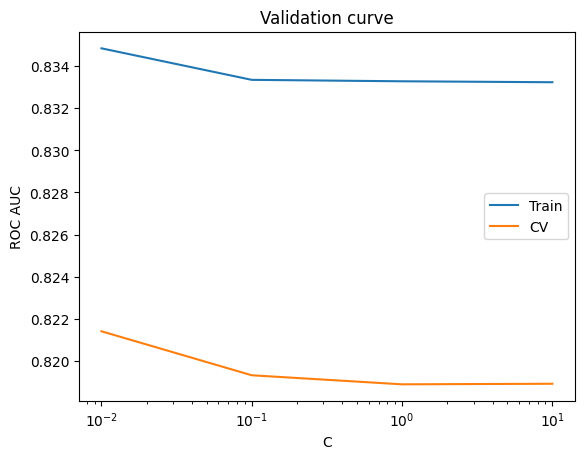

In [63]:
from sklearn.model_selection import validation_curve

param_range = [0.01, 0.1, 1, 10]
train_scores, test_scores = validation_curve(
    pipe, X, y,
    param_name="clf__C",
    param_range=param_range,
    cv=5,
    scoring="roc_auc"
)

plt.plot(param_range, train_scores.mean(axis=1), label="Train")
plt.plot(param_range, test_scores.mean(axis=1), label="CV")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("ROC AUC")
plt.legend()
plt.title("Validation curve")
plt.show()


In [64]:
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

best_threshold, f1[best_idx], prec[best_idx], rec[best_idx]


(np.float64(0.10099201057955924),
 np.float64(0.9244906107681428),
 np.float64(0.8740871317048602),
 np.float64(0.9810627473148672))

<Axes: title={'center': 'Permutation importance'}>

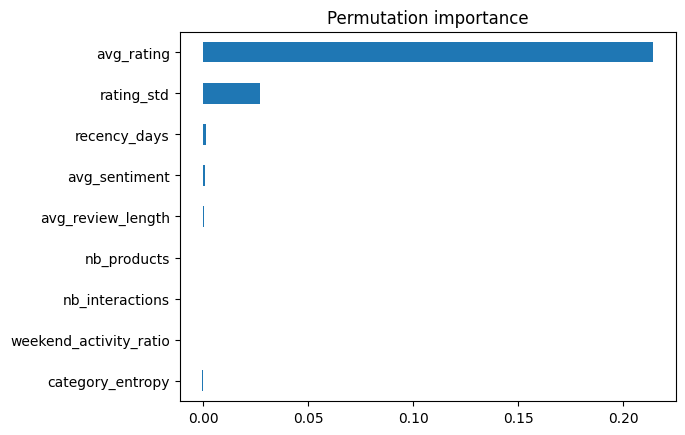

In [65]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, scoring="roc_auc", random_state=42
)

importances = pd.Series(r.importances_mean, index=feature_cols).sort_values()
importances.plot(kind="barh", title="Permutation importance")


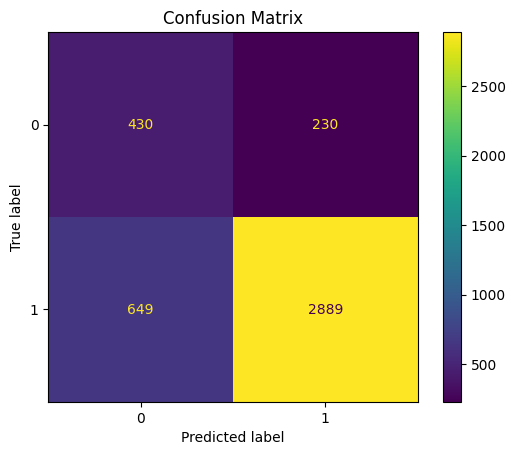

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()
